# finrisk-ai: End-to-End EDA and Modeling Notebook

This notebook demonstrates an end-to-end DS workflow:
- Data quality audit
- Target and feature analysis
- Benchmark modeling with cross-validation
- Clear business interpretation

In [12]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

DATA_PATH = '../data/raw/loan_prediction_dataset.csv'
TARGET_COL = 'Loan_Approved'

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (2000, 7)
Columns: ['Age', 'Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term', 'Employment_Status', 'Loan_Approved']


,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0
3,32,127188,364,16886,24,Unemployed,0
4,60,25655,307,26256,36,Unemployed,0


## 1) Data Quality Audit

In [13]:
profile = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
    'n_unique': df.nunique(),
})
profile

,dtype,missing_count,missing_pct,n_unique
Age,int64,0,0.0,52
Income,int64,0,0.0,1978
Credit_Score,int64,0,0.0,532
Loan_Amount,int64,0,0.0,1968
Loan_Term,int64,0,0.0,5
Employment_Status,object,0,0.0,3
Loan_Approved,int64,0,0.0,2


In [14]:
duplicate_count = df.duplicated().sum()
print(f'Duplicate rows: {duplicate_count}')

summary_stats = df.describe(include='all').T
summary_stats

Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,2000.0,NaN,NaN,NaN,43.8055,14.929203,18.0,31.0,44.0,56.0,69.0
Income,2000.0,NaN,NaN,NaN,84533.585,37771.169751,20155.0,50925.25,84073.5,117523.25,149992.0
Credit_Score,2000.0,NaN,NaN,NaN,577.055,157.525951,300.0,440.0,578.5,715.25,849.0
Loan_Amount,2000.0,NaN,NaN,NaN,25460.315,14116.737774,1060.0,13444.25,25446.0,37949.25,49994.0
Loan_Term,2000.0,NaN,NaN,NaN,35.478,16.98587,12.0,24.0,36.0,48.0,60.0
Employment_Status,2000,3,Employed,1260,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Loan_Approved,2000.0,NaN,NaN,NaN,0.171,0.376603,0.0,0.0,0.0,0.0,1.0


## 2) Target Analysis

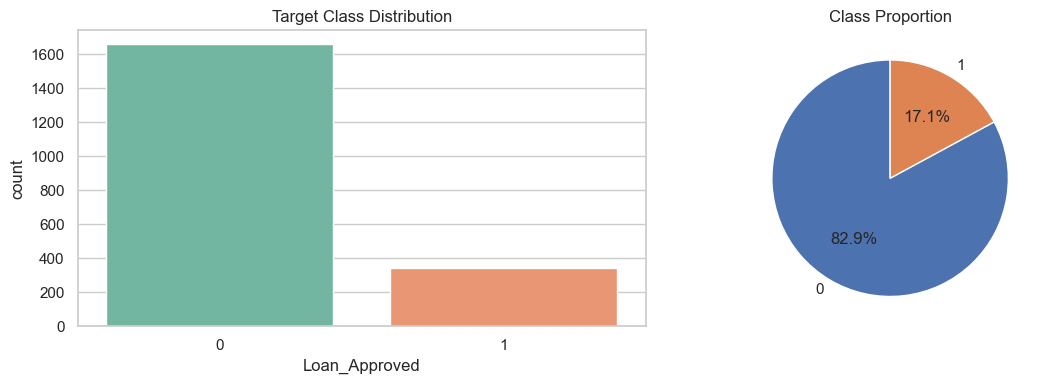

,count,pct
Loan_Approved,,
0,1658,82.9
1,342,17.1


In [15]:
target_dist = df[TARGET_COL].value_counts().sort_index()
class_ratio = (target_dist / len(df) * 100).round(2)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x=TARGET_COL, palette='Set2', ax=ax[0])
ax[0].set_title('Target Class Distribution')

ax[1].pie(target_dist.values, labels=target_dist.index, autopct='%1.1f%%', startangle=90)
ax[1].set_title('Class Proportion')

plt.tight_layout()
plt.show()

pd.DataFrame({'count': target_dist, 'pct': class_ratio})

In [16]:
majority_class = target_dist.idxmax()
naive_accuracy = target_dist.max() / len(df)
print(f'Naive baseline: always predict class {majority_class}')
print(f'Naive baseline accuracy: {naive_accuracy:.4f}')

Naive baseline: always predict class 0
Naive baseline accuracy: 0.8290


## 3) Correlation and Feature Behavior

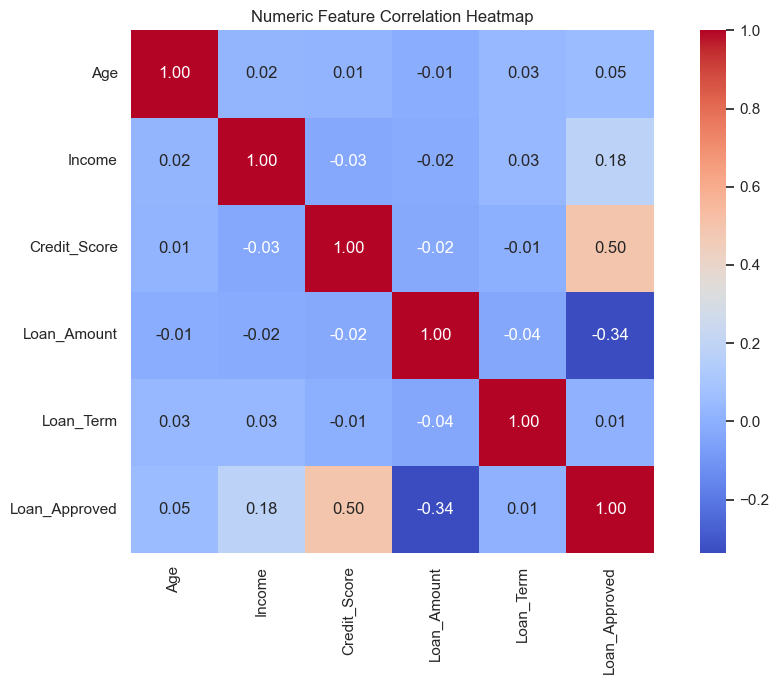

In [17]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
corr = df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Numeric Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

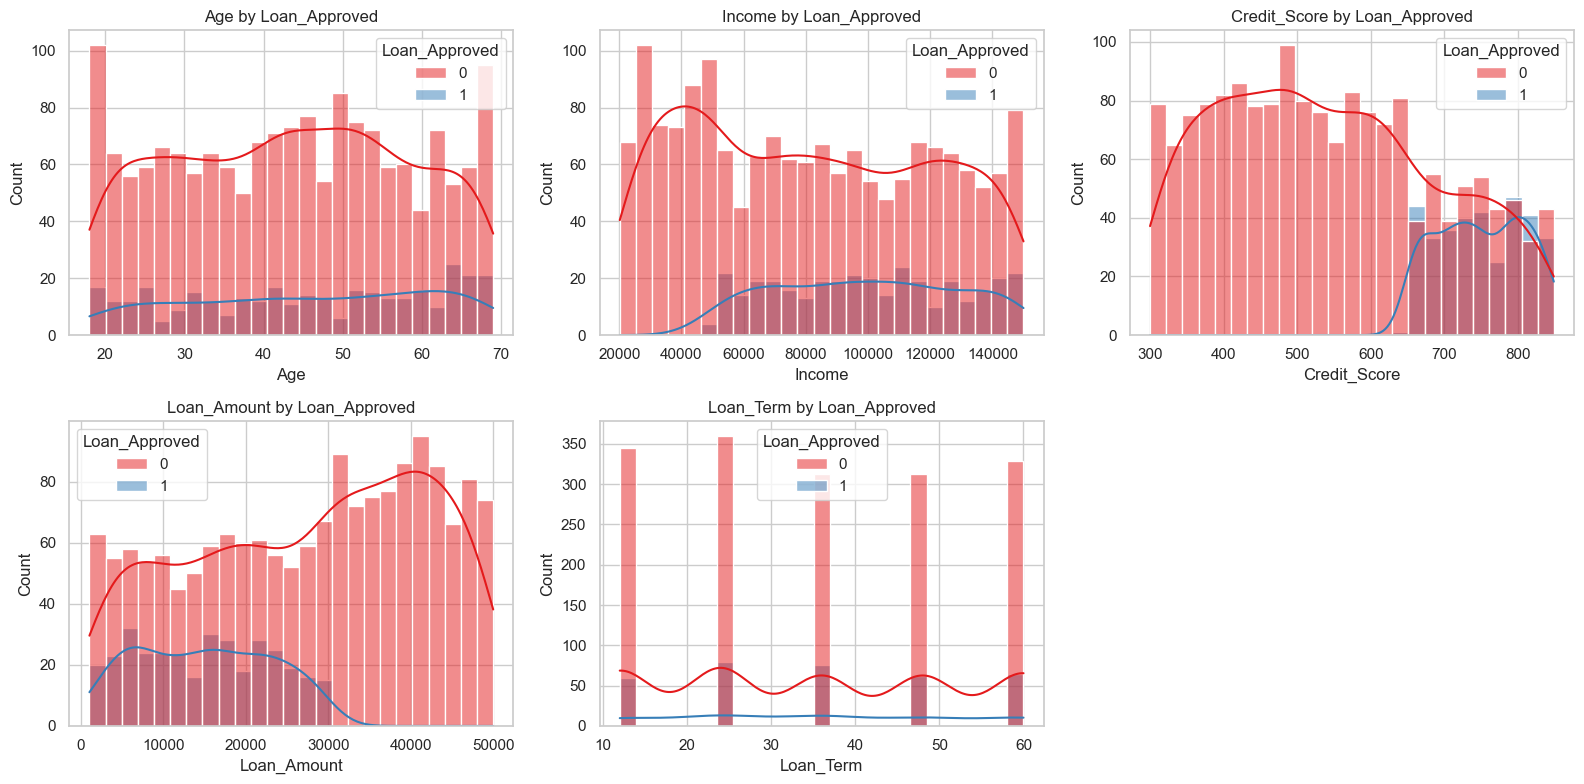

In [18]:
plot_cols = ['Age', 'Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(plot_cols):
    sns.histplot(data=df, x=col, hue=TARGET_COL, kde=True, bins=25, ax=axes[idx], palette='Set1', alpha=0.5)
    axes[idx].set_title(f'{col} by {TARGET_COL}')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

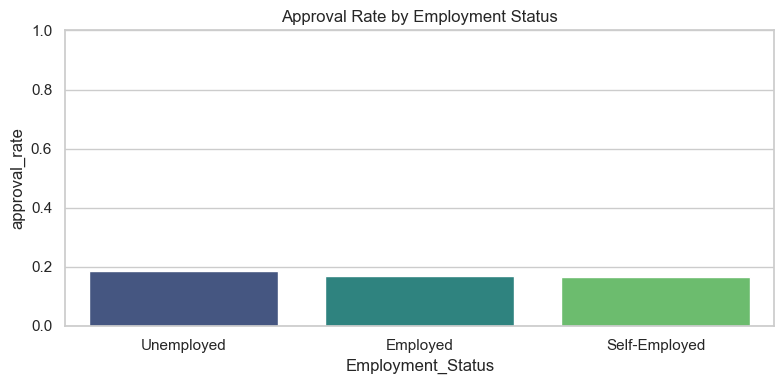

,count,approval_rate
Employment_Status,,
Unemployed,375,0.186667
Employed,1260,0.167460
Self-Employed,365,0.167123


In [19]:
approval_rate_by_employment = (
    df.groupby('Employment_Status')[TARGET_COL]
      .agg(['count', 'mean'])
      .rename(columns={'mean': 'approval_rate'})
      .sort_values('approval_rate', ascending=False)
)

plt.figure(figsize=(8, 4))
sns.barplot(data=approval_rate_by_employment.reset_index(), x='Employment_Status', y='approval_rate', palette='viridis')
plt.ylim(0, 1)
plt.title('Approval Rate by Employment Status')
plt.tight_layout()
plt.show()

approval_rate_by_employment

## 4) Model Benchmarking

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

X = df[['Age', 'Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term', 'Employment_Status']]
y = df[TARGET_COL]

numeric_features = ['Age', 'Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term']
categorical_features = ['Employment_Status']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_features),
    ]
)

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []

for name, model in models.items():
    pipeline = Pipeline([('preprocess', preprocessor), ('model', model)])
    scores = cross_validate(pipeline, X, y, cv=cv, scoring=['accuracy', 'precision', 'recall', 'f1'], n_jobs=-1)
    rows.append({
        'model': name,
        'cv_accuracy': np.mean(scores['test_accuracy']),
        'cv_precision': np.mean(scores['test_precision']),
        'cv_recall': np.mean(scores['test_recall']),
        'cv_f1': np.mean(scores['test_f1']),
    })

benchmark_df = pd.DataFrame(rows).sort_values('cv_f1', ascending=False)
benchmark_df

,model,cv_accuracy,cv_precision,cv_recall,cv_f1
2,DecisionTree,0.9990,1.00000,0.994160,0.997059
1,RandomForest,0.9975,1.00000,0.985422,0.992593
0,LogisticRegression,0.9215,0.79449,0.733802,0.761460


Best model (CV F1): DecisionTree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       332
           1       1.00      1.00      1.00        68

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



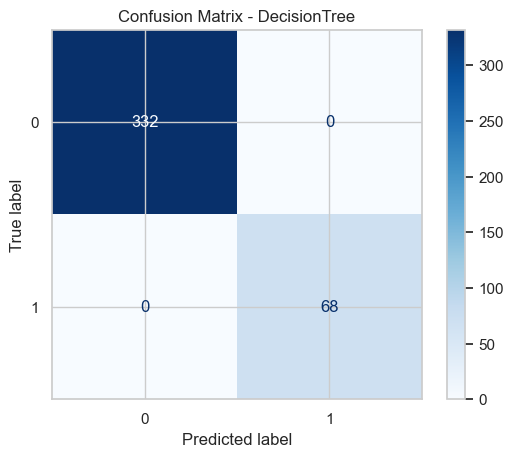

In [21]:
best_model_name = benchmark_df.iloc[0]['model']
best_model = models[best_model_name]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
final_pipeline = Pipeline([('preprocess', preprocessor), ('model', best_model)])
final_pipeline.fit(X_train, y_train)
y_pred = final_pipeline.predict(X_test)

print(f'Best model (CV F1): {best_model_name}')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

## 5) Validation Caveat

The very high tree-based scores indicate this dataset may be synthetic or highly rule-driven.
Treat this as a strong benchmark on this dataset, not guaranteed production generalization.

In [22]:
best_cv_f1 = benchmark_df['cv_f1'].max()
metric_gap = best_cv_f1 - naive_accuracy

print(f'Best CV F1: {best_cv_f1:.4f}')
print(f'Naive Accuracy Baseline: {naive_accuracy:.4f}')
print(f'Performance gap vs naive baseline: {metric_gap:.4f}')

Best CV F1: 0.9971
Naive Accuracy Baseline: 0.8290
Performance gap vs naive baseline: 0.1681
